In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Data Understanding

In [2]:
data = np.load("../data/mnist.npz")
print(data.files)

['x_test', 'x_train', 'y_train', 'y_test']


In [3]:
print("x_train:", data["x_train"].shape)
print("y_train:", data["y_train"].shape)
print("x_test :", data["x_test"].shape)
print("y_test :", data["y_test"].shape)

x_train: (60000, 28, 28)
y_train: (60000,)
x_test : (10000, 28, 28)
y_test : (10000,)


In [4]:
print("Image dtype:", data["x_train"].dtype)
print("Label dtype:", data["y_train"].dtype)

Image dtype: uint8
Label dtype: uint8


In [5]:
X_train = data["x_train"]
y_train = data["y_train"]

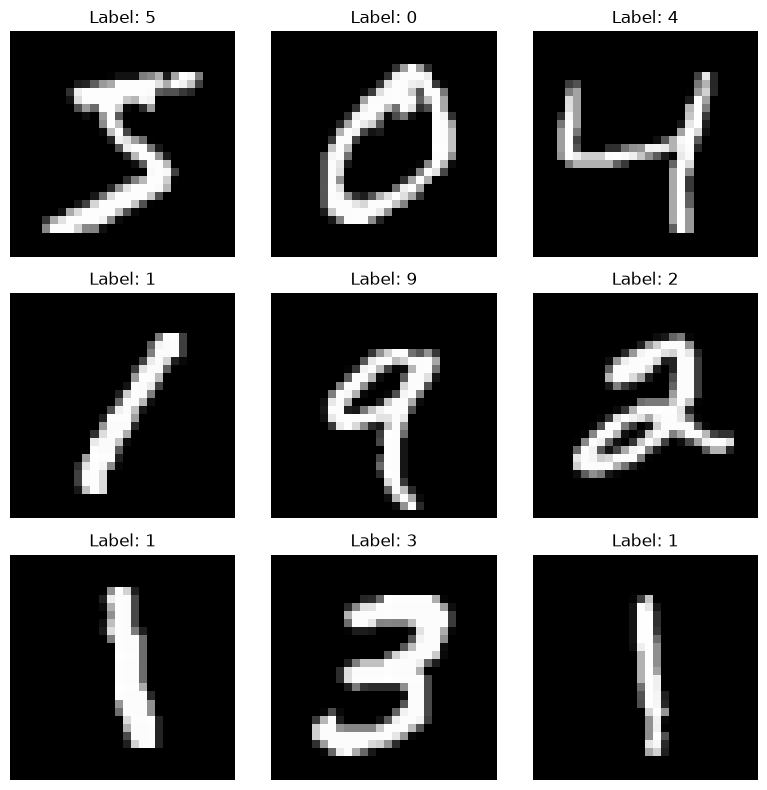

In [6]:
plt.figure(figsize=(8, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Data Preparation

In [7]:
X_test = data["x_test"]
y_test = data["y_test"]

In [8]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (60000, 28, 28)
y_train: (60000,)
X_test: (10000, 28, 28)
y_test: (10000,)


# Normalize the pixel values

In [9]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [10]:
print(X_train.dtype)
print(X_train.min())
print(X_train.max())

float32
0.0
1.0


# Flattening the images

In [11]:
X_train = X_train.reshape(X_train.shape[0], 784)
X_test = X_test.reshape(X_test.shape[0], 784)

In [12]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (60000, 784)
X_test: (10000, 784)


In [13]:
print("First 20 labels:", y_train[:20])
print("Unique labels:", np.unique(y_train))

First 20 labels: [5 0 4 1 9 2 1 3 1 4 3 5 3 6 1 7 2 8 6 9]
Unique labels: [0 1 2 3 4 5 6 7 8 9]


# Model building (Baseline)

In [14]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(784,)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

# Compiling model

In [16]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Training model

In [17]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.9266 - loss: 0.2508 - val_accuracy: 0.9690 - val_loss: 0.1073
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9681 - loss: 0.1039 - val_accuracy: 0.9708 - val_loss: 0.0904
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9780 - loss: 0.0720 - val_accuracy: 0.9772 - val_loss: 0.0887
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9829 - loss: 0.0546 - val_accuracy: 0.9782 - val_loss: 0.0789
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9862 - loss: 0.0436 - val_accuracy: 0.9722 - val_loss: 0.1121
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9891 - loss: 0.0342 - val_accuracy: 0.9710 - val_loss: 0.1048
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9910 - loss: 0.0275 - val_accuracy: 0.9787 - val_loss: 0.0786
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9920 - loss: 0.0250 -

# Evaluation

In [18]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9765 - loss: 0.1035


In [19]:
print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)

Test accuracy: 0.9764999747276306
Test loss: 0.1034500002861023


# Prediction

In [20]:
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 923us/step


# Converting probabilities into predicted digits

In [21]:
predicted_labels = np.argmax(predictions, axis=1)

In [22]:
cm = confusion_matrix(y_test, predicted_labels)
print(cm)

[[ 969    1    0    1    1    1    5    1    1    0]
 [   0 1127    1    1    0    2    2    0    2    0]
 [   5    1 1005    2    3    1    4    7    4    0]
 [   0    0    3  987    0    8    0    7    3    2]
 [   0    0    2    1  952    2    7    2    1   15]
 [   3    0    0    3    1  875    5    2    2    1]
 [   4    2    1    1    0    1  948    0    0    1]
 [   0    3   10    2    1    0    1 1007    1    3]
 [   6    2    2    8    8   12    6    6  922    2]
 [   1    2    0    6    4    3    1   19    0  973]]


# Visualizing 

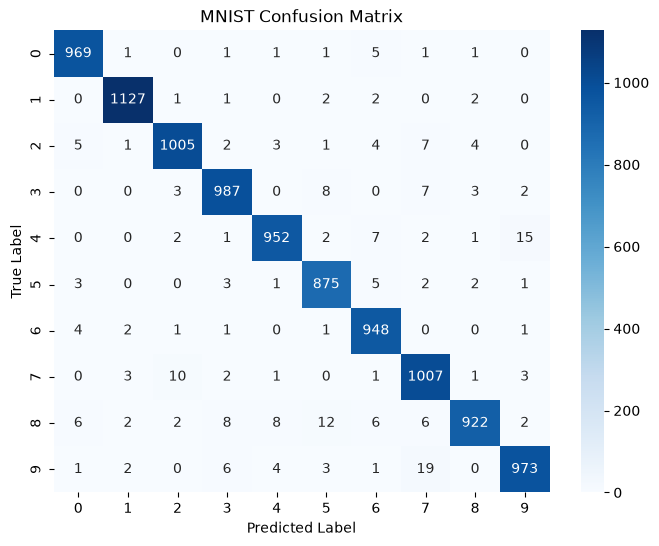

In [23]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MNIST Confusion Matrix")
plt.show()

# Finding wrong predictions

In [25]:
wrong_indices = np.where(y_test != predicted_labels)[0]
print("Number of wrong predictions:", len(wrong_indices))

Number of wrong predictions: 235


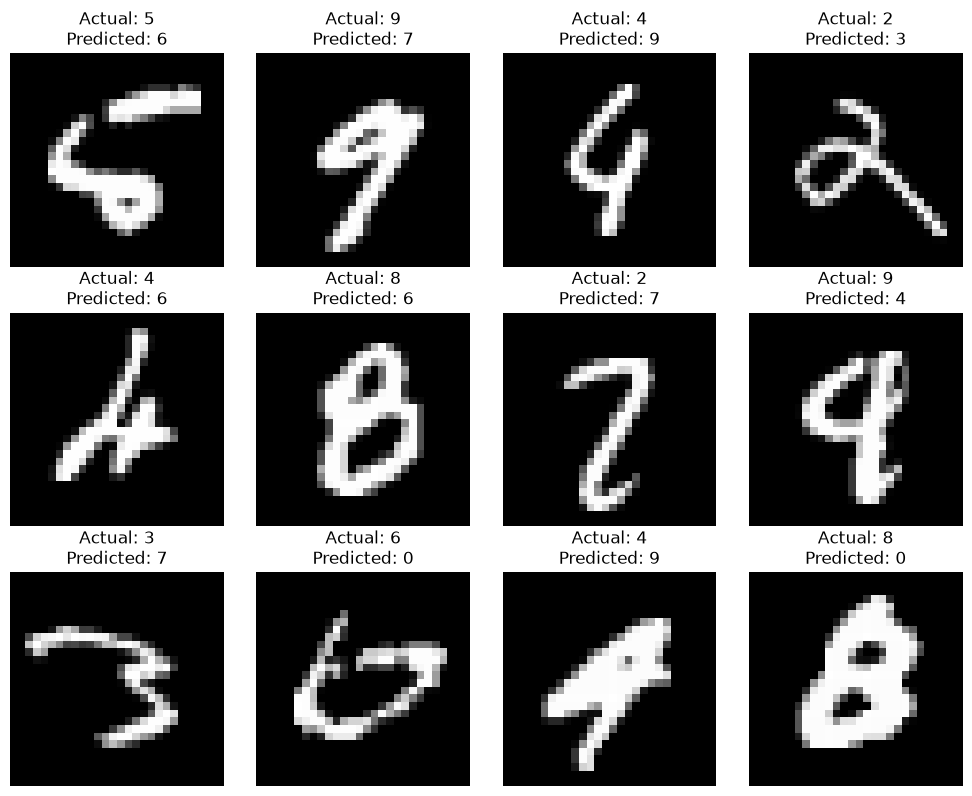

In [26]:
plt.figure(figsize=(10, 8))

for i, index in enumerate(wrong_indices[:12]):
    plt.subplot(3, 4, i + 1)

    plt.imshow(X_test[index].reshape(28, 28), cmap="gray")
    plt.title(
        f"Actual: {y_test[index]}\n"
        f"Predicted: {predicted_labels[index]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# Other Experiments 

# Experiment-0 (BaseLine)

Test accuracy: 0.9764999747276306   
Test loss: 0.1034500002861023

# Experiment-1

Increase epochs  
epochs=20

In [27]:
model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9942 - loss: 0.0179 - val_accuracy: 0.9803 - val_loss: 0.0899
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9954 - loss: 0.0144 - val_accuracy: 0.9793 - val_loss: 0.1008
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9954 - loss: 0.0142 - val_accuracy: 0.9770 - val_loss: 0.1100
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9952 - loss: 0.0146 - val_accuracy: 0.9798 - val_loss: 0.1103
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9964 - loss: 0.0109 - val_accuracy: 0.9765 - val_loss: 0.1226
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9960 - loss: 0.0119 - val_accuracy: 0.9798 - val_loss: 0.1137
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9960 - loss: 0.0112 - val_accuracy: 0.9797 - val_loss: 0.1206
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9959 - loss: 0.0120 - 

In [28]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9814 - loss: 0.1423
Test accuracy: 0.9814000129699707
Test loss: 0.1422894448041916


# Experiment-2

Increase batch size   
batch_size=64

In [29]:
model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9996 - loss: 0.0012 - val_accuracy: 0.9805 - val_loss: 0.1558
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9999 - loss: 6.5728e-04 - val_accuracy: 0.9813 - val_loss: 0.1435
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9993 - loss: 0.0022 - val_accuracy: 0.9795 - val_loss: 0.1841
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9973 - loss: 0.0086 - val_accuracy: 0.9820 - val_loss: 0.1615
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9992 - loss: 0.0029 - val_accuracy: 0.9828 - val_loss: 0.1539
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9994 - loss: 0.0019 - val_accuracy: 0.9812 - val_loss: 0.1770
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9991 - loss: 0.0030 - val_accuracy: 0.9820 - val_loss: 0.1561
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9986 - loss: 0.0048 - val_accuracy

In [30]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9826 - loss: 0.1500
Test accuracy: 0.9825999736785889
Test loss: 0.15003475546836853


# Experiment-3

Smaller batch size  
batch_size=16

In [31]:
model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=16,
    validation_split=0.1
)

Epoch 1/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9950 - loss: 0.0213 - val_accuracy: 0.9760 - val_loss: 0.1845
Epoch 2/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9961 - loss: 0.0146 - val_accuracy: 0.9767 - val_loss: 0.1903
Epoch 3/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9962 - loss: 0.0141 - val_accuracy: 0.9813 - val_loss: 0.1493
Epoch 4/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9961 - loss: 0.0141 - val_accuracy: 0.9768 - val_loss: 0.1874
Epoch 5/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9967 - loss: 0.0128 - val_accuracy: 0.9785 - val_loss: 0.1880
Epoch 6/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9960 - loss: 0.0155 - val_accuracy: 0.9767 - val_loss: 0.2048
Epoch 7/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9965 - loss: 0.0115 - val_accuracy: 0.9793 - val_loss: 0.1997
Epoch 8/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9964 - loss: 0.0145 - 

In [32]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9775 - loss: 0.2086
Test accuracy: 0.9775000214576721
Test loss: 0.2085711658000946


# Experiment-4 

Add another hidden layer  

In [33]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation="relu", input_shape=(784,)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

d:\Documents\Python\tf-env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [35]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9223 - loss: 0.2650 - val_accuracy: 0.9582 - val_loss: 0.1364
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9646 - loss: 0.1150 - val_accuracy: 0.9675 - val_loss: 0.1097
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9753 - loss: 0.0800 - val_accuracy: 0.9693 - val_loss: 0.1016
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9798 - loss: 0.0628 - val_accuracy: 0.9708 - val_loss: 0.0990
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9844 - loss: 0.0478 - val_accuracy: 0.9757 - val_loss: 0.0923
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9871 - loss: 0.0396 - val_accuracy: 0.9755 - val_loss: 0.1024
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9892 - loss: 0.0321 - val_accuracy: 0.9733 - val_loss: 0.1144
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9896 - loss: 0.0321 - 

In [36]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9725 - loss: 0.1129
Test accuracy: 0.9725000262260437
Test loss: 0.11292775720357895


# Experiment-5

Wider network

In [37]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation="relu", input_shape=(784,)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [38]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [39]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9343 - loss: 0.2197 - val_accuracy: 0.9710 - val_loss: 0.0938
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9715 - loss: 0.0892 - val_accuracy: 0.9783 - val_loss: 0.0723
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9815 - loss: 0.0591 - val_accuracy: 0.9763 - val_loss: 0.0817
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9841 - loss: 0.0476 - val_accuracy: 0.9812 - val_loss: 0.0729
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9878 - loss: 0.0369 - val_accuracy: 0.9793 - val_loss: 0.0744
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9901 - loss: 0.0302 - val_accuracy: 0.9792 - val_loss: 0.0746
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9922 - loss: 0.0245 - val_accuracy: 0.9798 - val_loss: 0.0788
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9931 - loss: 0.0210 - 

In [40]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9775 - loss: 0.0972
Test accuracy: 0.9775000214576721
Test loss: 0.09721807390451431


# Finalizing the Model (from Experiment-2)

In [41]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(784,)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [42]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [43]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9149 - loss: 0.2941 - val_accuracy: 0.9648 - val_loss: 0.1290
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9647 - loss: 0.1197 - val_accuracy: 0.9715 - val_loss: 0.1020
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9746 - loss: 0.0834 - val_accuracy: 0.9758 - val_loss: 0.0817
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9812 - loss: 0.0614 - val_accuracy: 0.9767 - val_loss: 0.0773
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9834 - loss: 0.0505 - val_accuracy: 0.9767 - val_loss: 0.0805
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9879 - loss: 0.0384 - val_accuracy: 0.9747 - val_loss: 0.0877
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9896 - loss: 0.0320 - val_accuracy: 0.9768 - val_loss: 0.0822
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9916 - loss: 0.0268 - val_accuracy: 0.

In [44]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9774 - loss: 0.0884
Test accuracy: 0.977400004863739
Test loss: 0.08836789429187775


In [45]:
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [46]:
predicted_labels = np.argmax(predictions, axis=1)

cm = confusion_matrix(y_test, predicted_labels)
print(cm)

[[ 971    0    2    1    0    0    1    0    4    1]
 [   0 1125    5    1    0    0    2    0    2    0]
 [   2    1 1015    1    2    0    1    6    4    0]
 [   0    0   13  974    0    5    0    6    6    6]
 [   1    0    6    0  961    0    2    3    2    7]
 [   3    0    1    4    2  870    4    0    6    2]
 [   1    3    1    1    4    5  940    0    3    0]
 [   0    4    8    1    0    0    0 1011    2    2]
 [   3    0    6    4    4    3    4    8  940    2]
 [   2    3    2    5   11    2    1   14    2  967]]


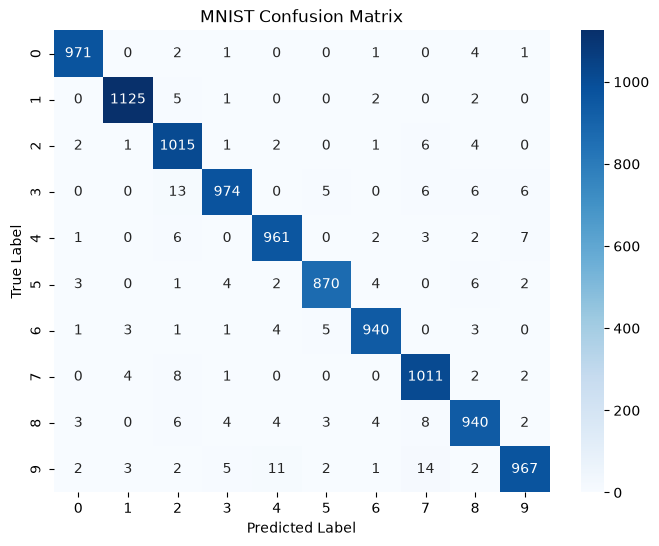

In [47]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MNIST Confusion Matrix")
plt.show()

In [48]:
wrong_indices = np.where(y_test != predicted_labels)[0]
print("Number of wrong predictions:", len(wrong_indices))

Number of wrong predictions: 226


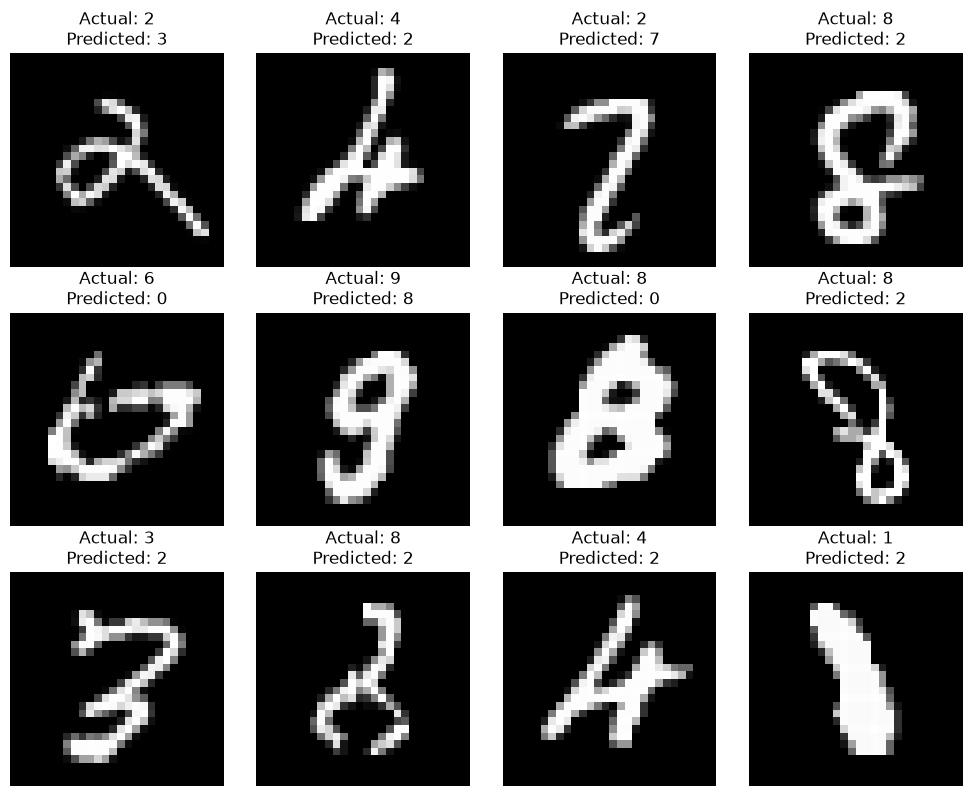

In [49]:
plt.figure(figsize=(10, 8))

for i, index in enumerate(wrong_indices[:12]):
    plt.subplot(3, 4, i + 1)

    plt.imshow(X_test[index].reshape(28, 28), cmap="gray")
    plt.title(
        f"Actual: {y_test[index]}\n"
        f"Predicted: {predicted_labels[index]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# Saving the final model

In [51]:
import joblib

joblib.dump(model, "../models/digit_recognizer_model.pkl")

['../models/digit_recognizer_model.pkl']